# Galactic Data Challange

## 1. Polarization fiting of Cyg-X1 using Stokes parameters method

1.1 The first step is to add the libraries.

In [3]:
from cosipy import BinnedData
from cosipy import UnBinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from cosipy.polarization.conventions import MEGAlibRelativeX, MEGAlibRelativeY, MEGAlibRelativeZ, IAUPolarizationConvention
from cosipy.polarization_fitting.polarization_stokes import (PolarizationStokes)

from astropy.time import Time
from astropy.coordinates import Angle, SkyCoord
from astropy import units as u

import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

%matplotlib inline

1.2 Then we make a folder for data.


In [2]:
data_path = Path("../cosi_galactic_constrain_geo_data/data")
data_path.mkdir(parents=True, exist_ok=True)


1.3 We download and load the orientation file.

In [3]:
ori_path = data_path/"DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori"

In [4]:

fetch_wasabi_file("COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori", ori_path)


A file named ../cosi_galactic_constrain_geo_data/data/DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori with the same ETag (ea0bf1fced99f3527579613debf4eaef-12) as the requested file already exists. Skipping.


In [4]:
ori_path = data_path/"DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori"
sc_orientation = SpacecraftHistory.open(ori_path)
sc_orientation = sc_orientation.select_interval(Time(1835487300.0, format = 'unix'), Time(1843467255.0, format = 'unix'))

1.4 We download the unbinned mock dataset parts and combine them.

In [6]:
mock_path = data_path/"mock_data"
mock_dir = Path(mock_path)
mock_dir.mkdir(exist_ok=True)

# Wasabi base path
wasabi_path = "COSI-SMEX/DC4/Data/Mock_Dataset"
file_name_list = []
for i in range(1, 15):
    filename = (
        f"dc4_mock_dataset_week_{i}_"
        "unbinned_data_filtered_with_SAAcut.fits.gz"
    )

    remote_file = f"{wasabi_path}/{filename}"
    local_file = mock_path / filename

    file_name_list.append(str(local_file))

    print(f"Downloading week {i}: {filename}")
    fetch_wasabi_file(remote_file, local_file)






A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_1_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (b57ceff199883040e659e5f770c41816-9) as the requested file already exists. Skipping.


A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_2_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (9981138e862a51c65fe8715ac074f2e5-9) as the requested file already exists. Skipping.


A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_3_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (494a319a302dd96a46d3ad6057e41fc2-9) as the requested file already exists. Skipping.


A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_4_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (6ea7f418cd80ab7f42999d5dbe46823b-9) as the requested file already exists. Skipping.


A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_5_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (9067a435a5fd4d87ea1e117c580919f9-9) as the requested file already exists. Skipping.


...

A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_10_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (e7b3f2afb48c32490ddda667fa425b25-8) as the requested file already exists. Skipping.


A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_11_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (3ef8b694e004edfe23fb875c0612d315-8) as the requested file already exists. Skipping.


A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_12_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (229965e05dd20171e90bd60d84d72b42-8) as the requested file already exists. Skipping.


A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_13_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (d9e94edd9cd8ad1fcd9309d20a688055-8) as the requested file already exists. Skipping.


A file named ../cosi_galactic_constrain_geo_data/data/mock_data/dc4_mock_dataset_week_14_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (0417506368746445b5bd47ced93a0c88-2) as the requested file already exists. Skipping.


In [7]:
mock_B = BinnedData("./cygX1_pol.yaml")
mock_B.combine_unbinned_data(file_name_list, output_name= data_path/"mock_total_unbinned_data")

1.5 We download the unbinned DC4 bakground.

In [5]:
background_path = data_path/"Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz"

In [9]:
fetch_wasabi_file("COSI-SMEX/DC4/Data/Backgrounds/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz", background_path)


A file named ../cosi_galactic_constrain_geo_data/data/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz with the same ETag (1c67e7a1517ef1b6042696f925296e22-3046) as the requested file already exists. Skipping.


1.6 We download the response files.

In [6]:
pol_response_path = data_path/"ResponseContinuum.o3.pol.e200_10000.b4.p12.relx.s10396905069491.m420.filtered.binnedpolarization.11D.h5"
fetch_wasabi_file("COSI-SMEX/DC4/Data/Responses/ResponseContinuum.o3.pol.e200_10000.b4.p12.relx.s10396905069491.m420.filtered.binnedpolarization.11D.h5", pol_response_path)

A file named ../cosi_galactic_constrain_geo_data/data/ResponseContinuum.o3.pol.e200_10000.b4.p12.relx.s10396905069491.m420.filtered.binnedpolarization.11D.h5 with the same ETag (9d0747ac5a717f8c5cf9cfaf94d8047c-9) as the requested file already exists. Skipping.


We look at the response.

In [7]:
from cosipy.response import FullDetectorResponse

pol_response_path = data_path/"ResponseContinuum.o3.pol.e200_10000.b4.p12.relx.s10396905069491.m420.filtered.binnedpolarization.11D.h5"
with FullDetectorResponse.open(pol_response_path,pa_convention="RelativeX") as response:

    print(response.axes.labels)
   

['NuLambda' 'Ei' 'Pol' 'Em' 'Phi' 'PsiChi']


1.7 We apply the energy cut on cygX1 and bkg unbinned data. This should be matched with the response file.

In [8]:
signal_path = data_path/"mock_total_unbinned_data.fits.gz"
mock_UB =  UnBinnedData('./cygX1_pol.yaml')
mock_UB.select_data_energy(200., 10000., output_name=data_path/'mock_UB_E_cut_200_10000', unbinned_data=signal_path)
mock_UB_E_cutted = mock_UB.get_dict_from_fits(data_path/'mock_UB_E_cut_200_10000.fits.gz')


In [1]:
bkg_UB =  UnBinnedData('./background_pol.yaml')
bkg_UB.select_data_energy(200., 10000., output_name=data_path/'bkg_UB_E_cut_200_10000', unbinned_data=background_path)
bkg_UB_E_cutted = bkg_UB.get_dict_from_fits(data_path/'bkg_UB_E_cut_200_10000.fits.gz')

NameError: name 'UnBinnedData' is not defined

1.8 Define the source direction and spectrum.

In [12]:
source_direction = SkyCoord(l=71.334, b=3.066, frame='galactic', unit=u.deg)

# Eqpair model
from astromodels.xspec.factory import *
from astromodels.xspec.xspec_settings import *


# ============================================================
# Load EQPAIR
# ============================================================
eqpair_spectrum = XS_eqpair()


# ============================================================
# EQPAIR setup for Cyg X-1 hard-state initial fit
# ============================================================


# ============================================================
# Stable EQPAIR setup for 3ML/COSI fitting
# Start with only the physically important continuum parameters free.
# ============================================================

# First freeze everything
for par in eqpair_spectrum.parameters.values():
    par.free = False


# ============================================================
# Main hard-to-soft compactness ratio.
# Controls the overall spectral hardness and is a useful fit parameter.
# ============================================================
eqpair_spectrum.l_hovl_s.value = 6.34
eqpair_spectrum.l_hovl_s.min_value = 2.0
eqpair_spectrum.l_hovl_s.max_value = 20.0
eqpair_spectrum.l_hovl_s.delta = 0.2
eqpair_spectrum.l_hovl_s.free = True

# ============================================================
# Seed-photon compactness.
# Often degenerate with l_hovl_s and normalization, so keep it fixed initially.
# ============================================================
eqpair_spectrum.l_bb.value = 1.0
eqpair_spectrum.l_bb.min_value = -15.0
eqpair_spectrum.l_bb.max_value = 35.0
eqpair_spectrum.l_bb.delta = 1.0
eqpair_spectrum.l_bb.free = False

# ============================================================
# Seed blackbody temperature.
# In this XSPEC EQPAIR implementation the value is specified in eV.
# ============================================================
eqpair_spectrum.kt_bb.value = 200.0
eqpair_spectrum.kt_bb.min_value = 50.0
eqpair_spectrum.kt_bb.max_value = 500.0
eqpair_spectrum.kt_bb.delta = 5.0
eqpair_spectrum.kt_bb.free = False

# ============================================================
# Fraction of hard compactness injected into nonthermal electrons.
# Important for the MeV tail; keep fixed until the basic continuum fit converges.
# ============================================================
eqpair_spectrum.l_ntol_h.value = 0.9
eqpair_spectrum.l_ntol_h.min_value = 0.0
eqpair_spectrum.l_ntol_h.max_value = 1.8
eqpair_spectrum.l_ntol_h.delta = 0.05
eqpair_spectrum.l_ntol_h.free = False

# ============================================================
# Thomson optical depth of background electrons.
# Controls spectral curvature and the cutoff; fit together with norm and l_hovl_s.
# ============================================================
eqpair_spectrum.tau_p.value = 1.29
eqpair_spectrum.tau_p.min_value = 0.3
eqpair_spectrum.tau_p.max_value = 4.0
eqpair_spectrum.tau_p.delta = 0.1
eqpair_spectrum.tau_p.free = True

# ============================================================
# Radius of the emitting region in cm.
# Usually weakly constrained by a COSI-only spectrum, so keep fixed initially.
# ============================================================
eqpair_spectrum.radius.value = 1.0e7
eqpair_spectrum.radius.min_value = 1.0e7
eqpair_spectrum.radius.max_value = 1.0e7
eqpair_spectrum.radius.delta = 1.0e5
eqpair_spectrum.radius.free = False

# ============================================================
# Minimum Lorentz factor of the injected nonthermal electron distribution.
# Keep fixed during the initial fit.
# ============================================================
eqpair_spectrum.g_min.value = 1.3
eqpair_spectrum.g_min.min_value = 1.2
eqpair_spectrum.g_min.max_value = 10.0
eqpair_spectrum.g_min.delta = 0.01
eqpair_spectrum.g_min.free = False

# ============================================================
# Maximum Lorentz factor of the injected nonthermal electron distribution.
# Keep fixed initially and free only if the high-energy tail requires adjustment.
# ============================================================
eqpair_spectrum.g_max.value = 1000.0
eqpair_spectrum.g_max.min_value = 100.0
eqpair_spectrum.g_max.max_value = 10000.0
eqpair_spectrum.g_max.delta = 100.0
eqpair_spectrum.g_max.free = False

# ============================================================
# Power-law index of the injected nonthermal electron distribution.
# Keep fixed until the continuum fit is stable.
# ============================================================
eqpair_spectrum.g_inj.value = 2.9
eqpair_spectrum.g_inj.min_value = 1.0
eqpair_spectrum.g_inj.max_value = 5.0
eqpair_spectrum.g_inj.delta = 0.1
eqpair_spectrum.g_inj.free = False

# ============================================================
# Pair-injection control parameter.
# Set to zero when no additional pair injection is included.
# ============================================================
eqpair_spectrum.pairinj.value = 0.0
eqpair_spectrum.pairinj.min_value = 0.0
eqpair_spectrum.pairinj.max_value = 0.0
eqpair_spectrum.pairinj.delta = 0.1
eqpair_spectrum.pairinj.free = False

# ============================================================
# Cosine of the inclination angle used by the reflection component.
# Keep fixed initially because it is usually weakly constrained by COSI-only data.
# ============================================================
eqpair_spectrum.cosincl.value = 0.891
eqpair_spectrum.cosincl.min_value = 0.05
eqpair_spectrum.cosincl.max_value = 0.95
eqpair_spectrum.cosincl.delta = 0.05
eqpair_spectrum.cosincl.free = False

# ============================================================
# Reflection scaling factor.
# Keep fixed initially and free only after the continuum parameters converge.
# ============================================================
eqpair_spectrum.refl.value = 0.25
eqpair_spectrum.refl.min_value = 0.0
eqpair_spectrum.refl.max_value = 1.0
eqpair_spectrum.refl.delta = 0.1
eqpair_spectrum.refl.free = False

# ============================================================
# Iron abundance relative to the reference abundance.
# Keep fixed initially unless reflection features provide useful constraints.
# ============================================================
eqpair_spectrum.fe_abund.value = 1.0
eqpair_spectrum.fe_abund.min_value = 0.1
eqpair_spectrum.fe_abund.max_value = 10.0
eqpair_spectrum.fe_abund.delta = 0.1
eqpair_spectrum.fe_abund.free = False

# ============================================================
# Overall metal abundance relative to the reference abundance.
# Keep fixed initially unless reflection features provide useful constraints.
# ============================================================
eqpair_spectrum.ab_met.value = 1.0
eqpair_spectrum.ab_met.min_value = 0.1
eqpair_spectrum.ab_met.max_value = 10.0
eqpair_spectrum.ab_met.delta = 0.1
eqpair_spectrum.ab_met.free = False

# ============================================================
# Disk temperature parameter used by the reflection treatment.
# Keep fixed initially.
# ============================================================
eqpair_spectrum.t_disk.value = 1.0e6
eqpair_spectrum.t_disk.min_value = 1.0e6
eqpair_spectrum.t_disk.max_value = 1.0e6
eqpair_spectrum.t_disk.delta = 10.0
eqpair_spectrum.t_disk.free = False

# ============================================================
# Ionization parameter of the reflector.
# A value of zero corresponds to a neutral reflector.
# ============================================================
eqpair_spectrum.xi.value = 0.0
eqpair_spectrum.xi.min_value = 0.0
eqpair_spectrum.xi.max_value = 0.0
eqpair_spectrum.xi.delta = 10.0
eqpair_spectrum.xi.free = False

# ============================================================
# Radial emissivity index of the reflection component.
# Keep fixed initially.
# ============================================================
eqpair_spectrum.beta.value = -10.0
eqpair_spectrum.beta.min_value = -10.0
eqpair_spectrum.beta.max_value = -10.0
eqpair_spectrum.beta.delta = 0.1
eqpair_spectrum.beta.free = False

# ============================================================
# Inner disk radius used by the reflection model.
# Keep fixed initially.
# ============================================================
eqpair_spectrum.rin.value = 10.0
eqpair_spectrum.rin.min_value = 10.0
eqpair_spectrum.rin.max_value = 10.0
eqpair_spectrum.rin.delta = 0.1
eqpair_spectrum.rin.free = False

# ============================================================
# Outer disk radius used by the reflection model.
# Keep fixed initially.
# ============================================================
eqpair_spectrum.rout.value = 1000.0
eqpair_spectrum.rout.min_value = 1000.0
eqpair_spectrum.rout.max_value = 1000.0
eqpair_spectrum.rout.delta = 1.0
eqpair_spectrum.rout.free = False

# ============================================================
# Source redshift.
# For the Galactic source Cyg X-1, keep this fixed at zero.
# ============================================================
eqpair_spectrum.redshift.value = 0.0
eqpair_spectrum.redshift.min_value = 0.0
eqpair_spectrum.redshift.max_value = 0.0
eqpair_spectrum.redshift.delta = 0.01
eqpair_spectrum.redshift.free = False

# ============================================================
# Overall EQPAIR normalization.
# Fit this parameter with a bounded range to avoid unstable likelihood evaluations.
# ============================================================
eqpair_spectrum.norm.value = 5.2e-8
eqpair_spectrum.norm.min_value = 1.0e-10
eqpair_spectrum.norm.max_value = 1.0e-6
eqpair_spectrum.norm.delta = 1.0e-9
eqpair_spectrum.norm.free = True

# ============================================================
# Display the spectrum parameters and setup before fitting.
# ============================================================
eqpair_spectrum.display()


Loading xspec models...done


* description: The eqpair model from XSpec (https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
  * formula: $n.a.$
  * parameters:
    * l_hovl_s:
      * value: 6.34
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 2.0
      * max_value: 20.0
      * unit: ''
      * is_normalization: false
      * delta: 0.2
      * free: true
    * l_bb:
      * value: 1.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: -15.0
      * max_value: 35.0
      * unit: ''
      * is_normalization: false
      * delta: 1.0
      * free: false
    * kt_bb:
      * value: 200.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 50.0
      * max_value: 500.0
      * unit: eV
      * is_normalization: false
      * delta: 5.0
      * free: false
    * l_ntol_h:
      * value: 0.9
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.0
      * max_value: 1.8
      * unit: ''
      * is_normalization: false
      * delta: 0.05
      * free: false
    * tau_p:
      * value: 1.29
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.3
      * max_value: 4.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: true
    * radius:
      * value: 10000000.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 10000000.0
      * max_value: 10000000.0
      * unit: cm
      * is_normalization: false
      * delta: 100000.0
      * free: false
    * g_min:
      * value: 1.3
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 1.2
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.01
      * free: false
    * g_max:
      * value: 1000.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 100.0
      * max_value: 10000.0
      * unit: ''
      * is_normalization: false
      * delta: 100.0
      * free: false
    * g_inj:
      * value: 2.9
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 1.0
      * max_value: 5.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * pairinj:
      * value: 0.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.0
      * max_value: 0.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * cosincl:
      * value: 0.891
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.05
      * max_value: 0.95
      * unit: ''
      * is_normalization: false
      * delta: 0.05
      * free: false
    * refl:
      * value: 0.25
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.0
      * max_value: 1.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * fe_abund:
      * value: 1.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.1
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * ab_met:
      * value: 1.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 0.1
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * t_disk:
      * value: 1000000.0
      * desc: (see https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XspecModels.html)
      * min_value: 1000000.0
      * max_value: 1000000.0
      * unit: K
      * is_normalization: false
      * 

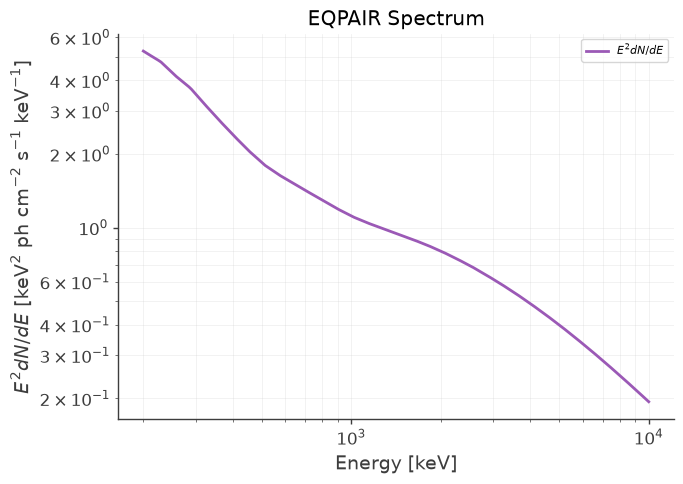

      
          EQPAIR V1.10
Uses ireflct for Compton reflection and rdblur for rotational blurring


In [13]:
# ============================================================
# Energy grid in keV
# ============================================================
energies = np.logspace(np.log10(200), np.log10(10000), 200)

# ============================================================
# Evaluate EQPAIR: dN/dE
# ============================================================
dnde = eqpair_spectrum(energies)

# Convert Quantity to plain numpy array if needed
try:
    dnde = dnde.value
except AttributeError:
    pass

# ============================================================
# Compute E^2 dN/dE
# ============================================================
e2dnde = energies**2 * dnde

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(
    energies,
    e2dnde,
    lw=2,
    label=r"$E^2 dN/dE$"
)

ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$E^2 dN/dE$ [keV$^2$ ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")
ax.set_title("EQPAIR Spectrum")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

1.9 Define the source position and polarization object.

In [14]:
source_photons = PolarizationStokes(source_direction, eqpair_spectrum, mock_UB_E_cutted, pol_response_path, sc_orientation, 
                                    background=bkg_UB_E_cutted, response_convention='RelativeX', show_plots=False)


This class loading takes around 30 seconds... 

Number of azimuthal angle bins used: 12
>>> Convolving spectrum in ICRS frame...
Energy range considered (by responses design): 200.0 - 10000.0 keV
Background provided. Make sure there is enough statistics.
Creating the 100% polarized ASADs (this may take a minute...)
Creating the unpolarized ASAD...
A = 0.69, B = 0.61, C = 1.43
Rmax, Rmin: 1.3046657906882613 0.7040693766440321
Modulation mu =  0.2989923329922346
A = 0.69, B = 0.62, C = 1.17
Rmax, Rmin: 1.3065691707570952 0.6997663296746796
Modulation mu =  0.30244335553641366
A = 0.69, B = 0.61, C = 0.91
Rmax, Rmin: 1.3057082183097823 0.6979011791861109
Modulation mu =  0.30335605327231313
A = 0.69, B = 0.62, C = 0.65
Rmax, Rmin: 1.3071965288518421 0.6944745572860253
Modulation mu =  0.3061052216865638
A = 0.69, B = 0.62, C = 0.39
Rmax, Rmin: 1.3030422563580795 0.6952084708446626
Modulation mu =  0.30418294222982467
A = 0.69, B = 0.62, C = 3.27
Rmax, Rmin: 1.3006976326848743 0.6943419498

Let's check some numbers:

In [15]:
data_duration = source_photons.get_data_duration()
data_count = source_photons.get_data_counts()
print('\nData duration:', str(round(data_duration, 3)), 's')
print('Data counts:', str(data_count))
print('Count rate:', str(round(data_count / data_duration, 3)), 'counts/s')

background_duration = source_photons.get_background_duration()
print('\nBackground duration:', str(round(background_duration, 3)), 's')

MDP99 = source_photons._mdp99 * 100
print('\nMDP_99:', str(round(MDP99, 3)), '%')


Data duration: 7979954.851 s
Data counts: 130962927
Count rate: 16.411 counts/s

Background duration: 7979954.831 s

MDP_99: 0.172 %


In [16]:
average_mu = source_photons._mu100
mu = average_mu['mu']
mu_err = average_mu['uncertainty']

print('modulation factor: %.3f +/- %.3f'%(mu, mu_err))

modulation factor: 0.303 +/- 0.000


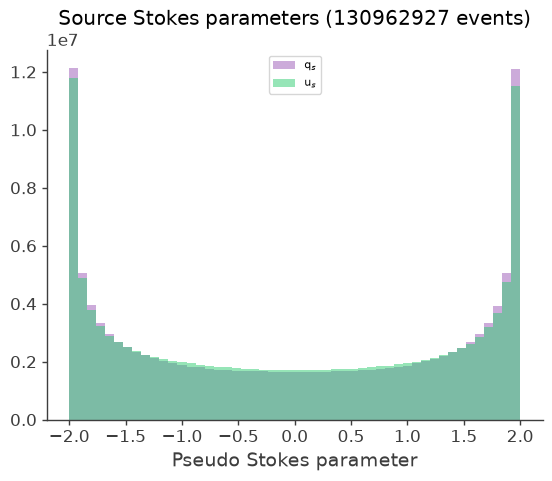

In [17]:
qs, us = source_photons.compute_data_pseudo_stokes(show_plots=True)

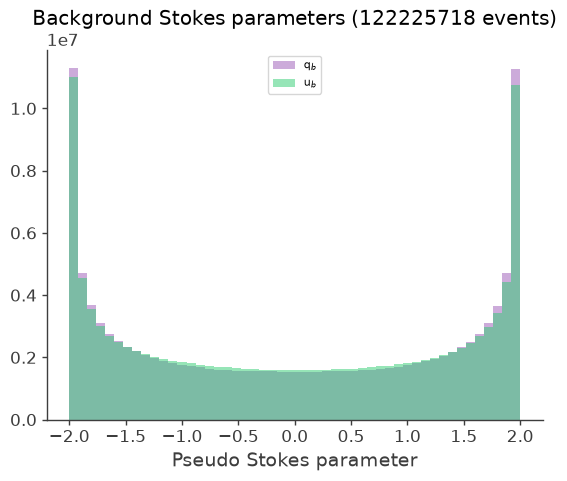

In [18]:
bkg_qs, bkg_us = source_photons.compute_background_pseudo_stokes(show_plots=True)

In [19]:
backscal = source_photons.get_backscal()

print('Background scale factor:', backscal)
print('Consistency check :', data_duration/background_duration == backscal)

Background scale factor: 1.0000000025262055
Consistency check : True



--- Data (source + background) ---
I = 130962927.0
Q = -1377580.426839924
U = -5193571.978537315
Q/I = -0.010518857957717485
U/I = -0.03965681049979369

--- Background ---
BACKSCAL = 1.0000000025262055
Scaled background I = 122225718.30876727
Scaled background Q = -1597787.9111807442
Scaled background U = -4275692.117742143

--- Net source after background subtraction ---
Net I = 8737208.691232726
Net Q = 220207.48434082023
Net U = -917879.8607951719

Net Q/I = 0.025203413598416786
Net U/I = -0.10505413035586643

##############################
PD: 10.80 +/- 0.03 %
PA: 141.75 +/- 0.08 deg
##############################



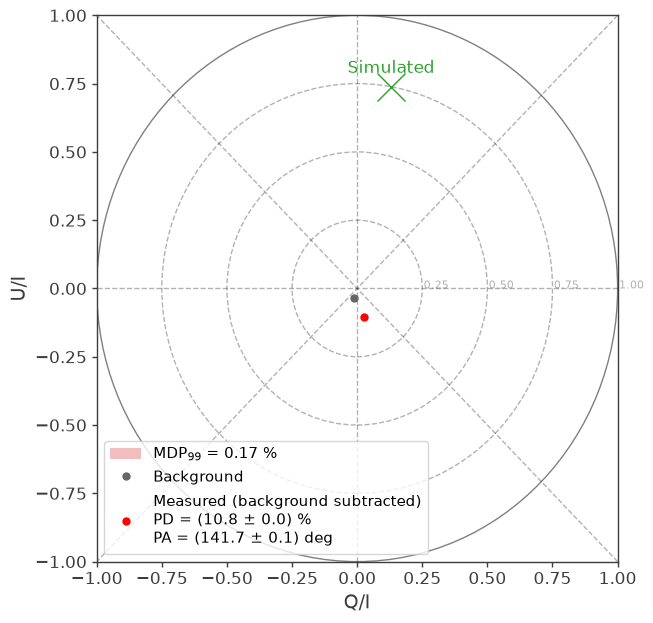

In [20]:
polarization = source_photons.calculate_polarization(qs, us, mu, bkg_qs=bkg_qs, bkg_us=bkg_us, show_plots=True, ref_pdpa=(0.75, 40), ref_label='Simulated', mdp=MDP99/100)


In [21]:
Pol_frac = polarization['fraction'] * 100
Pol_frac_err = polarization['fraction_uncertainty'] * 100
print('Polarization degree: (%.2f +/- %.2f) %%'%(Pol_frac, Pol_frac_err))

Pol_angle = polarization['angle'].angle.degree
Pol_angle_err = polarization['angle_uncertainty'].degree
print('Polarization angle: (%.2f +/- %.2f) deg'%(Pol_angle, Pol_angle_err))

Normalized_Q = polarization['QN']
Normalized_U = polarization['UN']
QN_ERR = polarization['QN_ERR']
UN_ERR = polarization['UN_ERR']
print('Normalized Q: %.3f +/- %.3f'%(Normalized_Q, QN_ERR))
print('Normalized U: %.3f +/- %.3f'%(Normalized_U, UN_ERR))

Polarization degree: (10.80 +/- 0.03) %
Polarization angle: (141.75 +/- 0.08) deg
Normalized Q: 0.025 +/- 0.000
Normalized U: -0.105 +/- 0.000
